In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ Librerías importadas correctamente
   pandas  2.2.2
   numpy   1.26.4
   seaborn 0.13.2


In [2]:
# ── CELDA 2: Carga de datos desde CSV ────────────────────────
df = pd.read_csv("../data/superheroes.csv")

print("✅ Datos cargados exitosamente")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

print("\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente
   Filas    : 730
   Columnas : 18

📋 Primeras filas:


,id,nombre,inteligencia,fuerza,velocidad,durabilidad,poder,combate,nombre_completo,editor,alineacion,genero,raza,altura,peso,fecha_extraccion,promedio_poder,ranking
0,1,A-Bomb,38,100,17,80,24,64,Richard Milhouse Jones,Marvel Comics,good,Male,Human,"6'8, 203 cm","980 lb, 441 kg",2026-03-27 17:56:27,53.83,328.0
1,2,Abe Sapien,88,28,35,65,100,85,Abraham Sapien,Dark Horse Comics,good,Male,Icthyo Sapien,"6'3, 191 cm","145 lb, 65 kg",2026-03-27 17:56:27,66.83,173.0
2,3,Abin Sur,50,90,53,64,99,65,NaN,DC Comics,good,Male,Ungaran,"6'1, 185 cm","200 lb, 90 kg",2026-03-27 17:56:27,70.17,141.0
3,4,Abomination,63,80,53,90,62,95,Emil Blonsky,Marvel Comics,bad,Male,Human / Radiation,"6'8, 203 cm","980 lb, 441 kg",2026-03-27 17:56:27,73.83,114.0
4,5,Abraxas,88,63,83,100,100,55,Abraxas,Marvel Comics,bad,Male,Cosmic Entity,"-, 0 cm","- lb, 0 kg",2026-03-27 17:56:27,81.50,69.0


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)

print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n🦸‍♂️ Conteo por alineación:")
print(df["alineacion"].value_counts())

print("\n🏢 Conteo por editorial:")
print(df["editor"].value_counts())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                730 non-null    int64  
 1   nombre            730 non-null    object 
 2   inteligencia      730 non-null    int64  
 3   fuerza            730 non-null    int64  
 4   velocidad         730 non-null    int64  
 5   durabilidad       730 non-null    int64  
 6   poder             730 non-null    int64  
 7   combate           730 non-null    int64  
 8   nombre_completo   629 non-null    object 
 9   editor            715 non-null    object 
 10  alineacion        730 non-null    object 
 11  genero            730 non-null    object 
 12  raza              429 non-null    object 
 13  altura            730 non-null    object 
 14  peso              730 non-null    object 
 15  fecha_extraccion  730 non-null    object 
 16  promedio_p

In [4]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_num = ["inteligencia", "fuerza", "velocidad", "durabilidad", "poder", "combate"]

desc = df[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       inteligencia  fuerza  velocidad  durabilidad   poder  combate
count        730.00  730.00     730.00       730.00  730.00   730.00
mean          49.97   37.91      31.21        45.72   49.81    47.76
std           32.16   34.10      27.29        36.15   37.52    32.93
min            0.00    0.00       0.00         0.00    0.00     0.00
25%           25.00   10.00       8.00        10.00   13.00    14.25
50%           56.00   28.00      27.00        42.00   50.00    56.00
75%           75.00   67.00      46.75        80.00   88.75    75.00
max          100.00  100.00     100.00       110.00  100.00   101.00


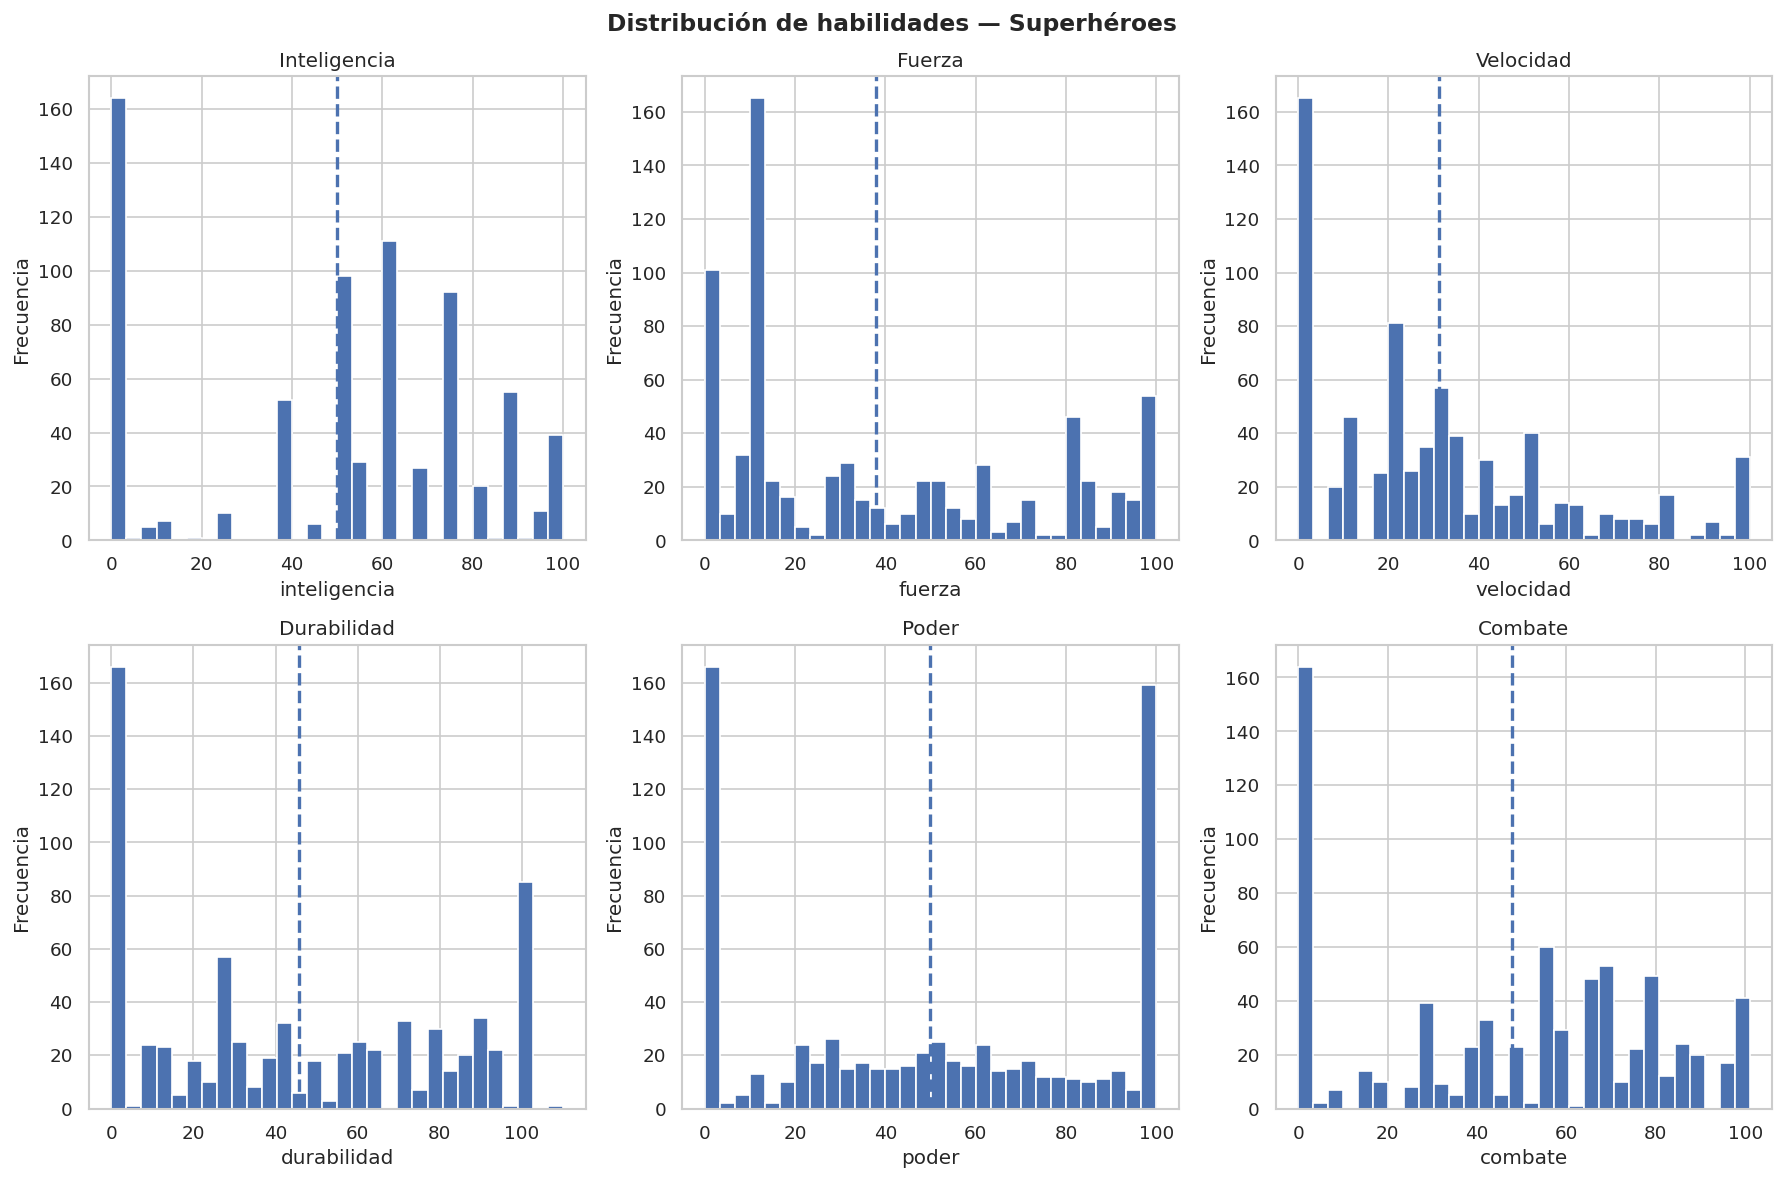

In [28]:
# ── CELDA 5: Distribución de variables ───────────────────────
import os
os.makedirs("../data/graficas", exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Distribución de habilidades — Superhéroes", fontsize=14, fontweight="bold")

vars_num = ["inteligencia", "fuerza", "velocidad", "durabilidad", "poder", "combate"]

for ax, col in zip(axes.flat, vars_num):
    ax.hist(df[col].dropna(), bins=30, edgecolor="white")
    media = df[col].mean()
    ax.axvline(media, linestyle="--", linewidth=2)
    ax.set_title(col.capitalize())
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

plt.tight_layout()


plt.savefig(
    "../data/graficas/eda_distribuciones.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

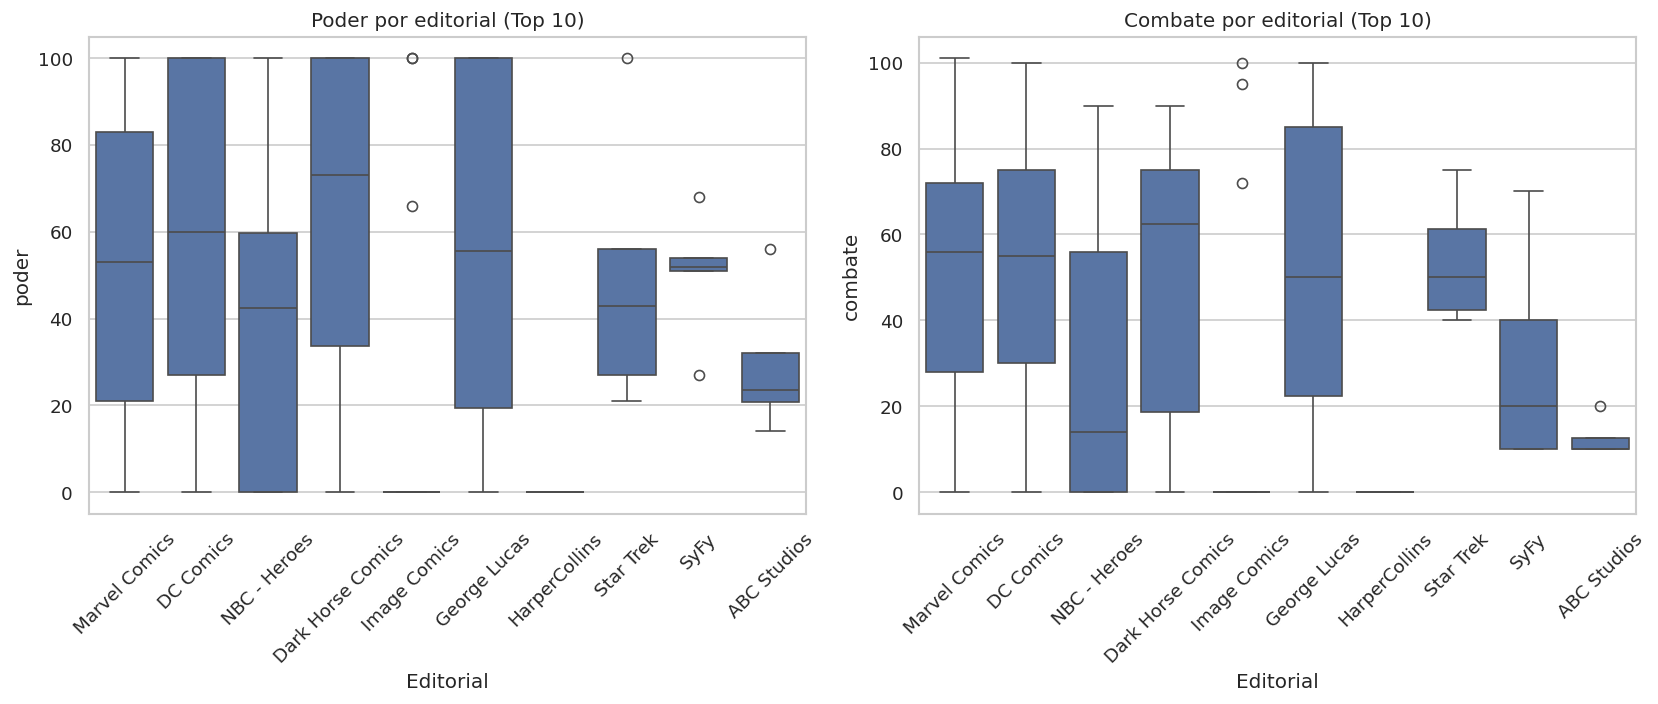

In [30]:
# ── CELDA 6: Boxplots por editorial (Top 10) ─────────────────
top10_editoriales = df["editor"].value_counts().head(10).index

df_top10 = df[df["editor"].isin(top10_editoriales)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_top10, x="editor", y="poder", order=top10_editoriales, ax=axes[0])
axes[0].set_title("Poder por editorial (Top 10)")
axes[0].set_xlabel("Editorial")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df_top10, x="editor", y="combate", order=top10_editoriales, ax=axes[1])
axes[1].set_title("Combate por editorial (Top 10)")
axes[1].set_xlabel("Editorial")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(
    "../data/graficas/eda_boxplots_top10.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

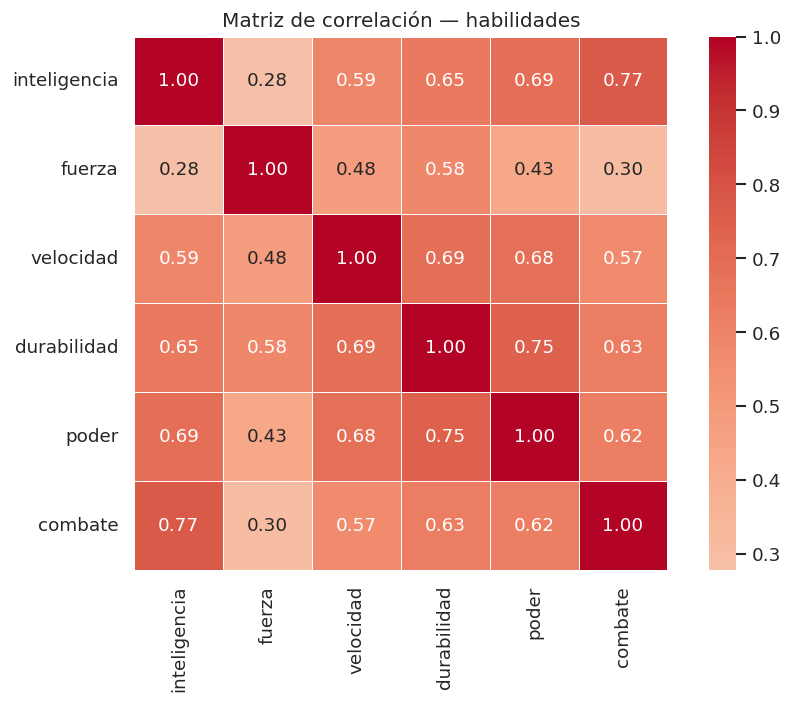


📊 Correlación con combate:
combate         1.000000
inteligencia    0.767891
durabilidad     0.628409
poder           0.621297
velocidad       0.565833
fuerza          0.301764
Name: combate, dtype: float64


In [39]:
# ── CELDA 7: Matriz de correlación (mejorada) ────────────────
import os
os.makedirs("../data/graficas", exist_ok=True)

vars_num = ["inteligencia", "fuerza", "velocidad", "durabilidad", "poder", "combate"]

# 🔥 limpiar datos
df_corr = df[vars_num].copy()

for col in vars_num:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

df_corr = df_corr.dropna()

# correlación
corr = df_corr.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Matriz de correlación — habilidades")

plt.tight_layout()

# 👇 guardar
plt.savefig(
    "../data/graficas/eda_correlacion.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("\n📊 Correlación con combate:")
print(corr["combate"].sort_values(ascending=False))

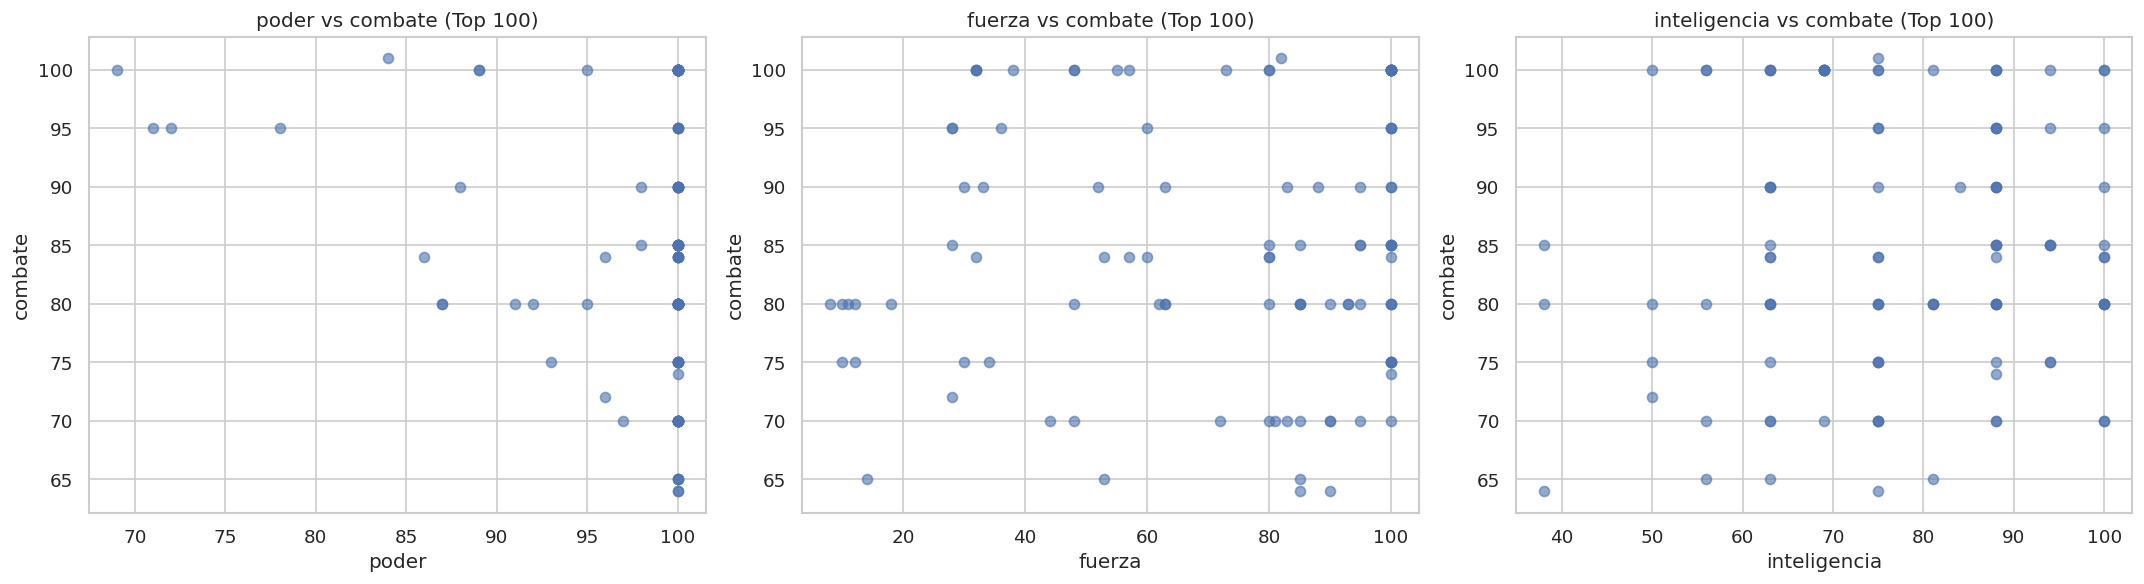

In [31]:
# ── CELDA 8: Scatter plots (Top 100) ─────────────────────────
df_scatter = df.copy()

# convertir por si acaso
cols = ["poder", "combate", "fuerza", "inteligencia"]
for col in cols:
    df_scatter[col] = pd.to_numeric(df_scatter[col], errors="coerce")

df_scatter = df_scatter.dropna(subset=cols)

# 🔥 filtro: top 100 por poder + combate
df_scatter["score"] = df_scatter["poder"] + df_scatter["combate"]
df_scatter = df_scatter.sort_values("score", ascending=False).head(100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pares = [
    ("poder", "combate"),
    ("fuerza", "combate"),
    ("inteligencia", "combate")
]

for ax, (x, y) in zip(axes, pares):
    ax.scatter(df_scatter[x], df_scatter[y], alpha=0.6)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y} (Top 100)")

plt.tight_layout()
plt.savefig(
    "../data/graficas/eda_scatter_top.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [9]:
# ── CELDA 9: Split Train / Test ───────────────────────────────
from sklearn.model_selection import train_test_split

X_simple = df[["poder"]].values
y = df["combate"].values

# eliminar nulos
mask = ~pd.isnull(X_simple.flatten()) & ~pd.isnull(y)
X_simple = X_simple[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras")
print(f"Test : {X_test.shape[0]:,} muestras")

Train: 584 muestras
Test : 146 muestras


In [10]:
# ── CELDA 10: Entrenamiento ──────────────────────────────────
from sklearn.linear_model import LinearRegression

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")

print(f"\nEcuación:")
print(f"combate = {modelo_simple.intercept_:.3f} + {modelo_simple.coef_[0]:.3f} × poder")

Intercepto  β₀ : 19.9504
Coeficiente β₁ : 0.5527

Ecuación:
combate = 19.950 + 0.553 × poder


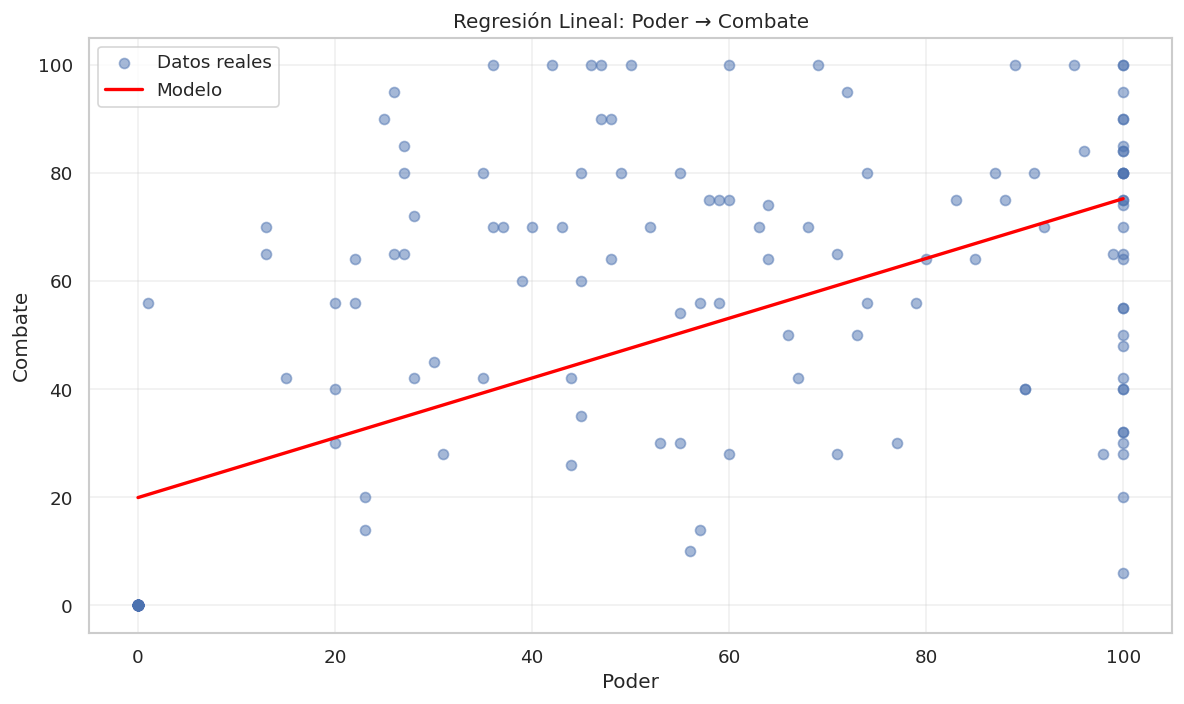

In [32]:
# ── CELDA 11: Visualización (mejorada + guardado) ────────────
fig, ax = plt.subplots(figsize=(10, 6))

# puntos (datos reales)
ax.scatter(X_test, y_test, alpha=0.5, label="Datos reales")

# línea de regresión (ordenada)
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
y_line = modelo_simple.predict(x_line)

ax.plot(x_line, y_line, color="red", linewidth=2, label="Modelo")

ax.set_xlabel("Poder")
ax.set_ylabel("Combate")
ax.set_title("Regresión Lineal: Poder → Combate")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

# 👇 GUARDAR (ANTES de show)
plt.savefig(
    "../data/graficas/regresion_simple.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [12]:
# ── CELDA 12: Métricas ───────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2 = r2_score(y_test, y_pred_simple)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)

print("=" * 50)
print("📊 MÉTRICAS — REGRESIÓN LINEAL")
print("=" * 50)
print(f"R²   : {r2:.4f} ({r2*100:.2f}%)")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print("=" * 50)

📊 MÉTRICAS — REGRESIÓN LINEAL
R²   : 0.3239 (32.39%)
MSE  : 745.8301
RMSE : 27.3099
MAE  : 22.8856


In [13]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────
import statsmodels.api as sm

X_ols = sm.add_constant(df["poder"])  # agrega intercepto
y_ols = df["combate"]

# eliminar nulos
mask = ~pd.isnull(X_ols).any(axis=1) & ~pd.isnull(y_ols)
X_ols = X_ols[mask]
y_ols = y_ols[mask]

modelo_ols_simple = sm.OLS(y_ols, X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                combate   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     457.7
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           3.69e-79
Time:                        15:56:42   Log-Likelihood:                -3408.2
No. Observations:                 730   AIC:                             6820.
Df Residuals:                     728   BIC:                             6830.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.6007      1.589     12.965      0.0

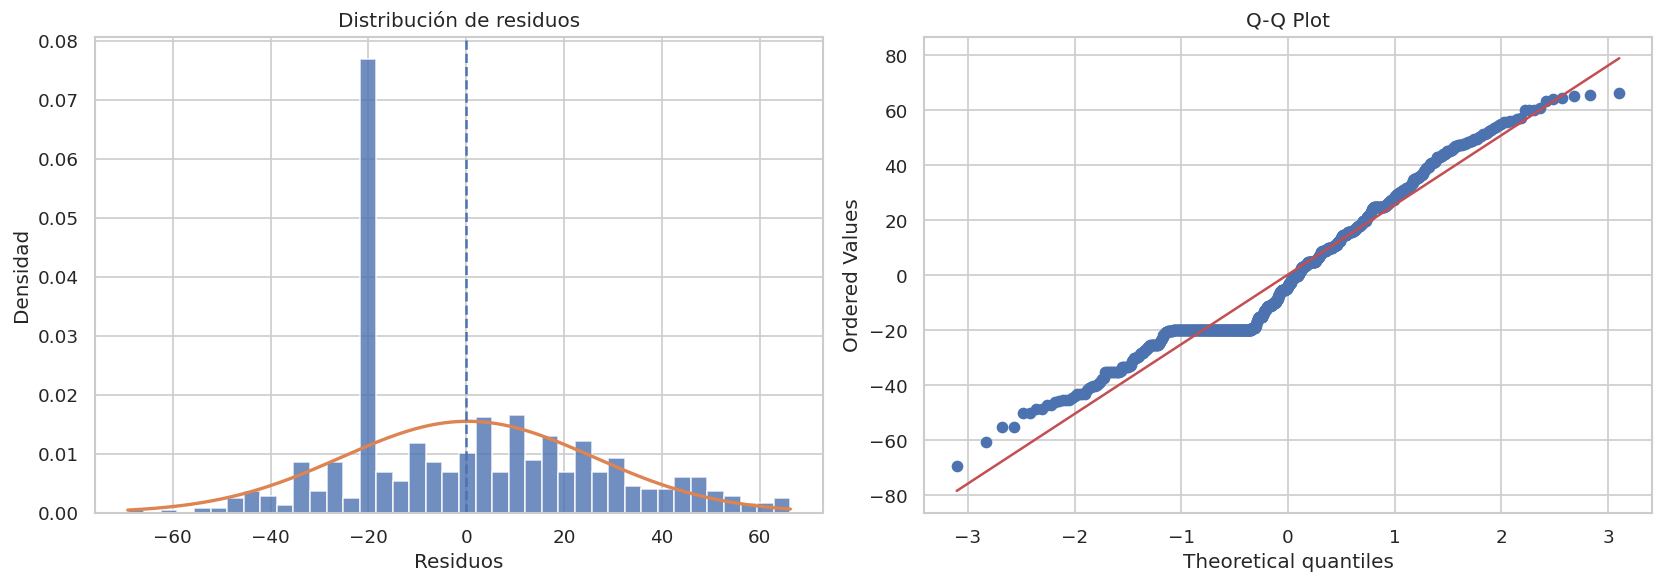


Shapiro-Wilk p-value: 0.000000
⚠️ No son normales (puede influir el tamaño de la muestra)


In [33]:
# ── CELDA 14: Normalidad de residuos ─────────────────────────
from scipy import stats

# preparar datos limpios
df_res = df[["poder", "combate"]].copy()
df_res["poder"] = pd.to_numeric(df_res["poder"], errors="coerce")
df_res["combate"] = pd.to_numeric(df_res["combate"], errors="coerce")
df_res = df_res.dropna()

# predicciones
y_pred_all = modelo_simple.predict(df_res[["poder"]].values)

# residuos
residuos = df_res["combate"].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(residuos, bins=40, density=True, alpha=0.8, edgecolor="white")
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos.mean(), residuos.std()),
    linewidth=2
)
axes[0].axvline(0, linestyle="--")
axes[0].set_title("Distribución de residuos")
axes[0].set_xlabel("Residuos")
axes[0].set_ylabel("Densidad")

# Q-Q Plot
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(
    "../data/graficas/normalidad_simple.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# Shapiro test
muestra = residuos if len(residuos) <= 5000 else np.random.choice(residuos, 5000, replace=False)
stat, p = stats.shapiro(muestra)

print(f"\nShapiro-Wilk p-value: {p:.6f}")

if p > 0.05:
    print("✅ Residuos normales")
else:
    print("⚠️ No son normales (puede influir el tamaño de la muestra)")

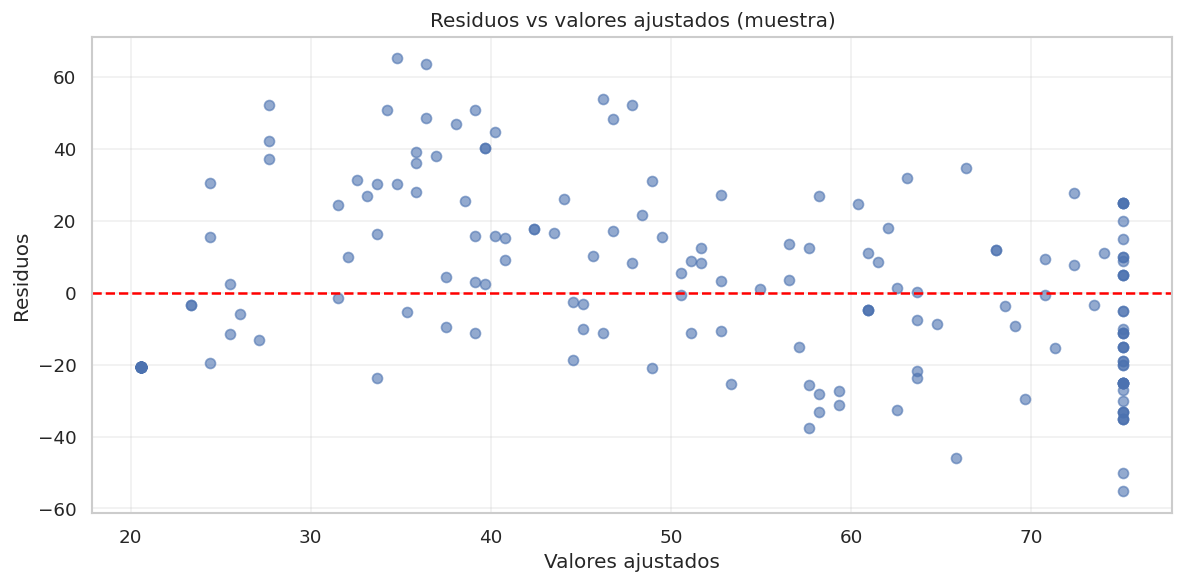


Breusch-Pagan p-value: 0.337524
✅ Homocedasticidad


In [35]:
# ── CELDA 15: Homocedasticidad (filtrado) ────────────────────
from statsmodels.stats.diagnostic import het_breuschpagan
import numpy as np

residuos_ols = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

# 🔥 filtro: tomar muestra aleatoria (máx 200 puntos)
n = min(200, len(residuos_ols))
idx = np.random.choice(len(residuos_ols), n, replace=False)

residuos_plot = residuos_ols.iloc[idx]
ajustados_plot = ajustados_ols.iloc[idx]

plt.figure(figsize=(10, 5))

plt.scatter(ajustados_plot, residuos_plot, alpha=0.6)

plt.axhline(0, linestyle="--", color="red")

plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados (muestra)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../data/graficas/homoc_simple.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# Test completo (sin filtrar)
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print(f"\nBreusch-Pagan p-value: {lm_p:.6f}")

if lm_p > 0.05:
    print("✅ Homocedasticidad")
else:
    print("⚠️ Heterocedasticidad")

In [17]:
# ── CELDA 16: Modelo múltiple ────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

FEATURES = ["poder", "fuerza", "inteligencia"]

# eliminar nulos
df_multi = df[FEATURES + ["combate"]].dropna()

X_multi = df_multi[FEATURES].values
y = df_multi["combate"].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto β₀ : {modelo_multi.intercept_:.4f}")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"{feat:>12} → {coef:.4f}")

Intercepto β₀ : 5.4126
       poder → 0.1419
      fuerza → 0.0793
inteligencia → 0.6424


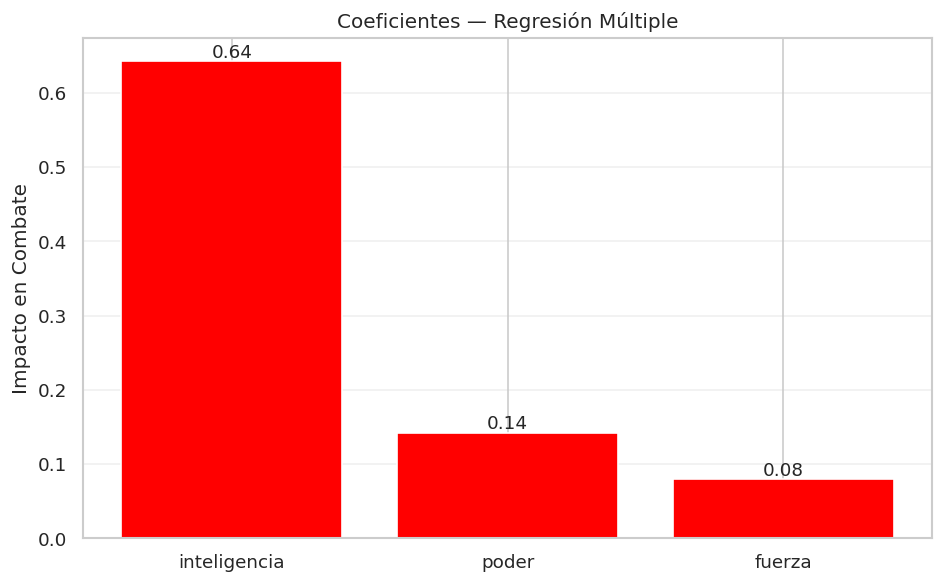

In [36]:
# ── CELDA 17: Coeficientes (mejorado) ────────────────────────
import numpy as np

coefs = modelo_multi.coef_

# 🔥 ordenar por importancia (más claro visualmente)
orden = np.argsort(np.abs(coefs))[::-1]
features_ord = [FEATURES[i] for i in orden]
coefs_ord = coefs[orden]

colores = ["red" if c > 0 else "blue" for c in coefs_ord]

plt.figure(figsize=(8, 5))

bars = plt.bar(features_ord, coefs_ord, color=colores)

plt.axhline(0, linestyle="--", color="black")

plt.title("Coeficientes — Regresión Múltiple")
plt.ylabel("Impacto en Combate")

# etiquetas más claras
for bar, coef in zip(bars, coefs_ord):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{coef:.2f}",
        ha="center",
        va="bottom" if coef > 0 else "top"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# 👇 GUARDAR
plt.savefig(
    "../data/graficas/coeficientes_multi.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [19]:
# ── CELDA 18: Métricas ───────────────────────────────────────
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_m = r2_score(y_test_m, y_pred_multi)
mse_m = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 50)
print("📊 MÉTRICAS — REGRESIÓN MÚLTIPLE")
print("=" * 50)
print(f"R²   : {r2_m:.4f} ({r2_m*100:.2f}%)")
print(f"MSE  : {mse_m:.4f}")
print(f"RMSE : {rmse_m:.4f}")
print(f"MAE  : {mae_m:.4f}")
print("=" * 50)

📊 MÉTRICAS — REGRESIÓN MÚLTIPLE
R²   : 0.5982 (59.82%)
MSE  : 443.2689
RMSE : 21.0540
MAE  : 16.6250


In [20]:
# ── CELDA 19: OLS múltiple ───────────────────────────────────
import statsmodels.api as sm

X_ols_m = sm.add_constant(df_multi[FEATURES])
y_ols_m = df_multi["combate"]

modelo_ols_multi = sm.OLS(y_ols_m, X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                combate   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     374.7
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          5.53e-147
Time:                        16:00:52   Log-Likelihood:                -3244.8
No. Observations:                 730   AIC:                             6498.
Df Residuals:                     726   BIC:                             6516.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.9777      1.517      3.941   

In [21]:
# ── CELDA 20: VIF ────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_multi[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data["VIF"] = vif_data["VIF"].round(3)

vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad" if v < 5
    else ("⚠️ Moderada" if v < 10 else "❌ Severa")
)

print(vif_data)

       Variable    VIF                 Criterio
0         poder  6.013              ⚠️ Moderada
1        fuerza  2.474  ✅ Sin multicolinealidad
2  inteligencia  5.236              ⚠️ Moderada


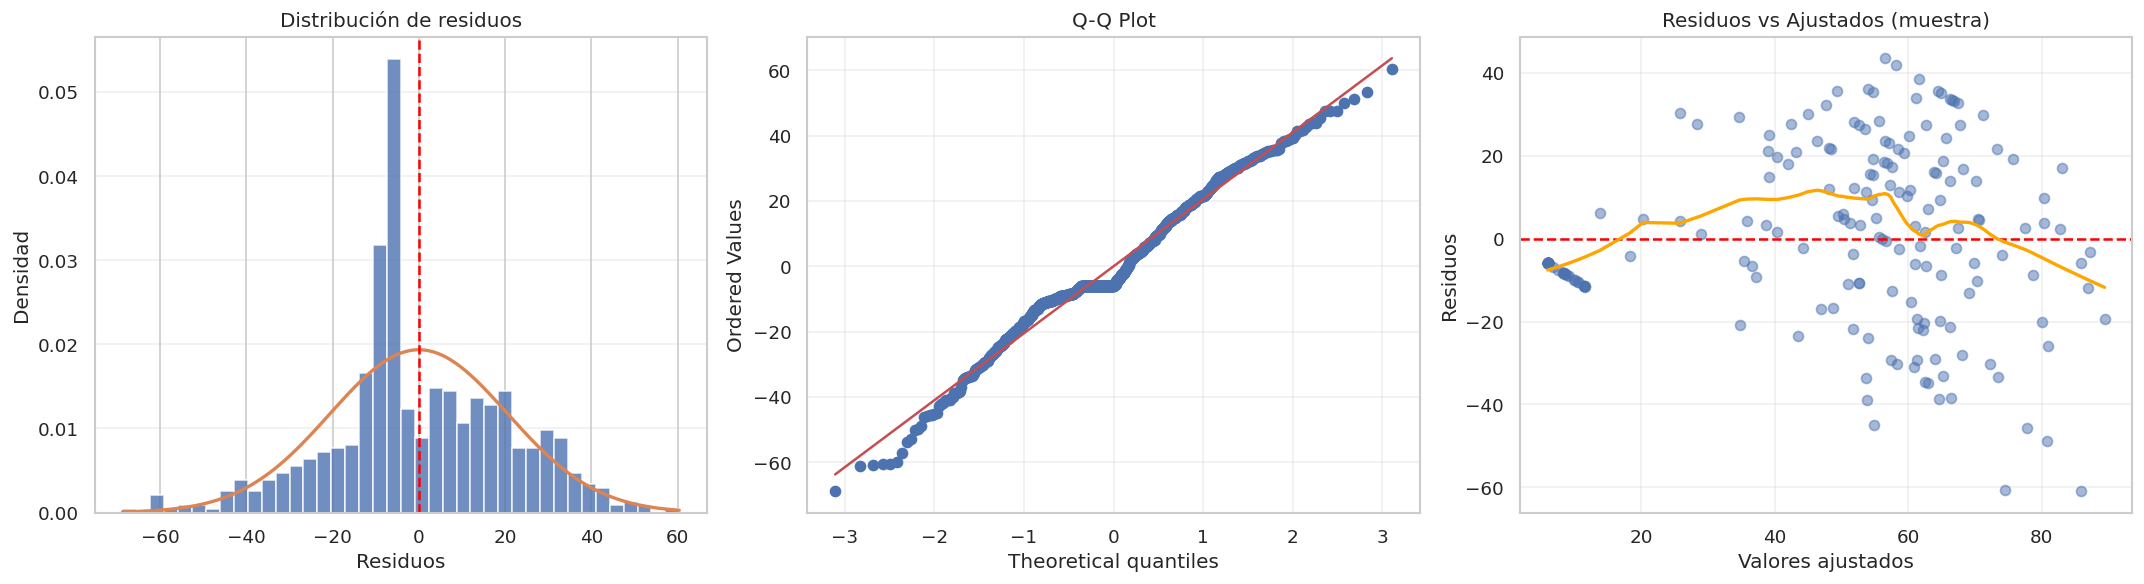

Shapiro p-value: 0.000000
⚠️ No normal
Breusch-Pagan p-value: 0.000000
⚠️ Heterocedasticidad


In [37]:
# ── CELDA 21: Diagnósticos (mejorado + filtrado) ─────────────
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import numpy as np

residuos_m = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Histograma de residuos
axes[0].hist(residuos_m, bins=40, density=True, alpha=0.8, edgecolor="white")
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
    linewidth=2
)
axes[0].axvline(0, linestyle="--", color="red")
axes[0].set_title("Distribución de residuos")
axes[0].set_xlabel("Residuos")
axes[0].set_ylabel("Densidad")
axes[0].grid(axis="y", alpha=0.3)

# ── Q-Q Plot
stats.probplot(residuos_m, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")
axes[1].grid(alpha=0.3)

# ── Residuos vs ajustados (filtrado visual)
n = min(200, len(residuos_m))
idx = np.random.choice(len(residuos_m), n, replace=False)

residuos_plot = residuos_m[idx]
ajustados_plot = ajustados_m[idx]

axes[2].scatter(ajustados_plot, residuos_plot, alpha=0.5)
axes[2].axhline(0, linestyle="--", color="red")

lowess = sm.nonparametric.lowess(residuos_plot, ajustados_plot, frac=0.3)
axes[2].plot(lowess[:, 0], lowess[:, 1], color="orange", linewidth=2)

axes[2].set_title("Residuos vs Ajustados (muestra)")
axes[2].set_xlabel("Valores ajustados")
axes[2].set_ylabel("Residuos")
axes[2].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../data/graficas/diagnosticos_multi.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# ── Tests estadísticos
muestra = residuos_m if len(residuos_m) <= 5000 else np.random.choice(residuos_m, 5000, replace=False)
stat_sw, p_sw = stats.shapiro(muestra)

print(f"Shapiro p-value: {p_sw:.6f}")
if p_sw > 0.05:
    print("✅ Normalidad OK")
else:
    print("⚠️ No normal")

lm, lm_p, _, _ = het_breuschpagan(modelo_ols_multi.resid, modelo_ols_multi.model.exog)

print(f"Breusch-Pagan p-value: {lm_p:.6f}")
if lm_p > 0.05:
    print("✅ Homocedasticidad")
else:
    print("⚠️ Heterocedasticidad")

In [23]:
# ── CELDA 22: Comparación ────────────────────────────────────
comparacion = pd.DataFrame({
    "Modelo": ["Simple", "Múltiple"],
    "Variables": ["poder", "poder + fuerza + inteligencia"],
    "R²": [round(r2, 4), round(r2_m, 4)],
    "R² Ajustado": [
        round(modelo_ols_simple.rsquared_adj, 4),
        round(modelo_ols_multi.rsquared_adj, 4)
    ],
    "RMSE": [round(rmse, 4), round(rmse_m, 4)],
    "MAE": [round(mae, 4), round(mae_m, 4)],
    "AIC": [
        round(modelo_ols_simple.aic, 2),
        round(modelo_ols_multi.aic, 2)
    ],
    "BIC": [
        round(modelo_ols_simple.bic, 2),
        round(modelo_ols_multi.bic, 2)
    ]
})

print(comparacion)

     Modelo                      Variables      R²  R² Ajustado     RMSE  \
0    Simple                          poder  0.3239       0.3852  27.3099   
1  Múltiple  poder + fuerza + inteligencia  0.5982       0.6060  21.0540   

       MAE      AIC      BIC  
0  22.8856  6820.37  6829.55  
1  16.6250  6497.52  6515.89  


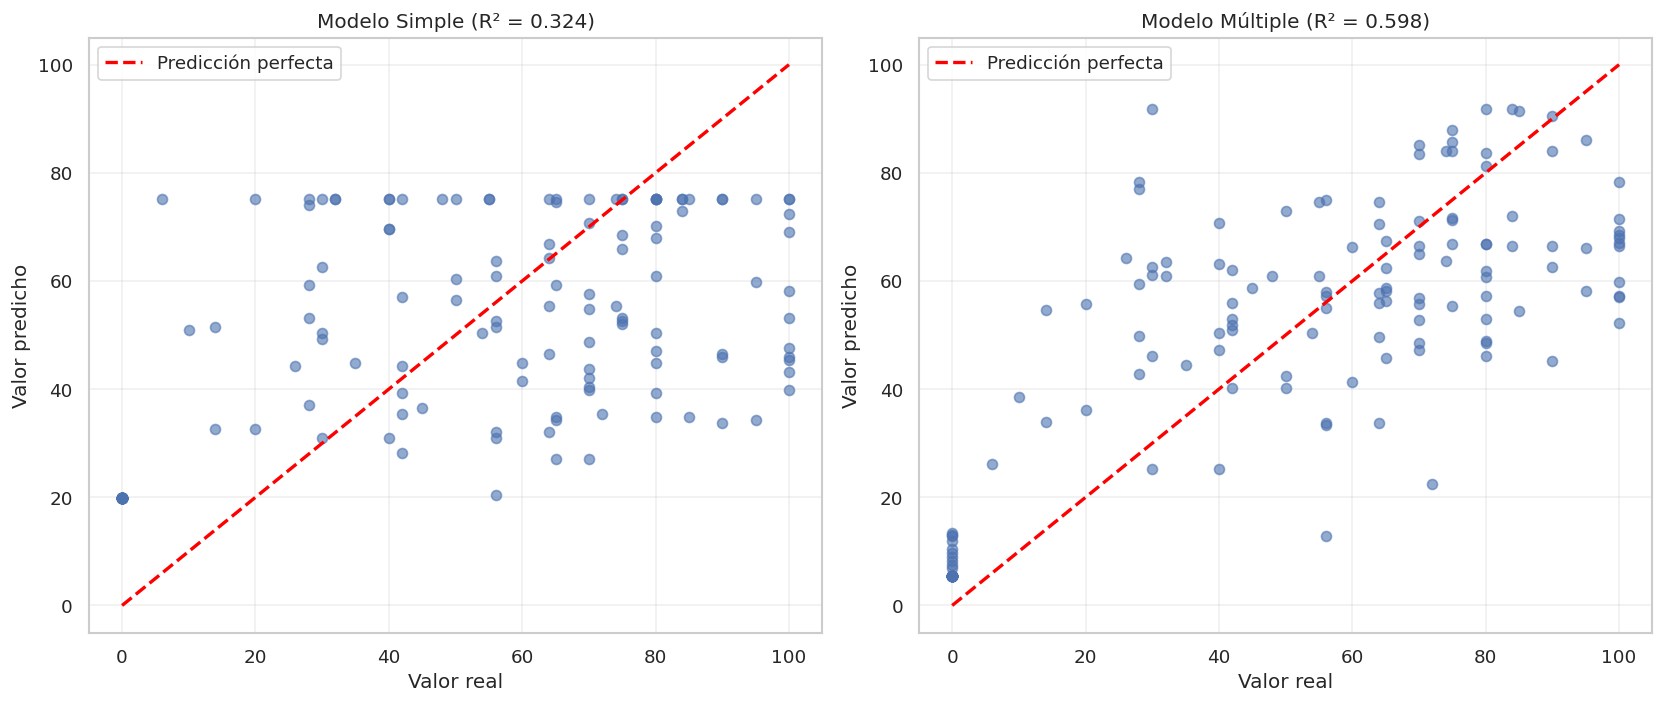

In [38]:
# ── CELDA 23: Predicción vs Real (filtrado) ──────────────────
import numpy as np
from sklearn.metrics import r2_score

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, "Modelo Simple"),
    (y_test_m, y_pred_multi,  "Modelo Múltiple"),
]):
    # convertir a arrays por seguridad
    y_real = np.array(y_real)
    y_pred = np.array(y_pred)

    # 🔥 filtro visual: muestra máxima de 150 puntos
    n = min(150, len(y_real))
    idx = np.random.choice(len(y_real), n, replace=False)

    y_real_plot = y_real[idx]
    y_pred_plot = y_pred[idx]

    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())

    ax.scatter(y_real_plot, y_pred_plot, alpha=0.6)
    ax.plot(
        [minval, maxval],
        [minval, maxval],
        linestyle="--",
        color="red",
        linewidth=2,
        label="Predicción perfecta"
    )

    r2_val = r2_score(y_real, y_pred)  # ✅ se calcula con todos los datos
    ax.set_title(f"{titulo} (R² = {r2_val:.3f})")
    ax.set_xlabel("Valor real")
    ax.set_ylabel("Valor predicho")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(
    "../data/graficas/predicciones_vs_reales.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()